# User Data Analysis Project
This notebook loads user data from `users.csv`, explores, cleans, analyzes, and visualizes the data using **pandas**, **matplotlib**, and **seaborn**.

## 1. Imports & Load Data

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import json

df = pd.read_csv('users.csv')
df.head()

,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,"{'address': '626 Main Street', 'city': 'Phoeni...",47:fa:41:18:ec:eb,University of Wisconsin--Madison,"{'cardExpire': '05/28', 'cardNumber': '3693233...","{'department': 'Engineering', 'name': 'Dooley,...",977-175,900-590-289,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
1,2,Michael,Williams,NaN,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,"{'address': '385 Fifth Street', 'city': 'Houst...",79:15:78:99:60:aa,Ohio State University,"{'cardExpire': '01/30', 'cardNumber': '3530633...","{'department': 'Support', 'name': 'Spinka - Di...",912-602,108-953-962,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
2,3,Sophia,Brown,NaN,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,"{'address': '1642 Ninth Street', 'city': 'Wash...",12:a3:d3:6f:5c:5b,Pepperdine University,"{'cardExpire': '10/27', 'cardNumber': '6011212...","{'department': 'Research and Development', 'na...",963-113,638-461-822,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
3,4,James,Davis,NaN,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,"{'address': '238 Jefferson Street', 'city': 'S...",10:7d:df:1f:97:58,University of Southern California,"{'cardExpire': '07/30', 'cardNumber': '5303440...","{'department': 'Support', 'name': 'Pagac and S...",904-810,116-951-314,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,"{'address': '607 Fourth Street', 'city': 'Jack...",32:b9:7e:8d:f5:e8,Northeastern University,"{'cardExpire': '07/30', 'cardNumber': '5237188...","{'department': 'Human Resources', 'name': 'Gra...",403-505,526-210-885,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin


## 2. Basic Data Exploration

In [2]:
# Shape
print(f"Shape of DataFrame: {df.shape}")

Shape of DataFrame: (208, 28)


In [3]:
# Column names
print(f"Column Names:\n{list(df.columns)}")

Column Names:
['id', 'firstName', 'lastName', 'maidenName', 'age', 'gender', 'email', 'phone', 'username', 'password', 'birthDate', 'image', 'bloodGroup', 'height', 'weight', 'eyeColor', 'hair', 'ip', 'address', 'macAddress', 'university', 'bank', 'company', 'ein', 'ssn', 'userAgent', 'crypto', 'role']


In [4]:
# Data types
print(f"Data Types:\n{df.dtypes}")

Data Types:
id              int64
firstName         str
lastName          str
maidenName        str
age             int64
gender            str
email             str
phone             str
username          str
password          str
birthDate         str
image             str
bloodGroup        str
height        float64
weight        float64
eyeColor          str
hair              str
ip                str
address           str
macAddress        str
university        str
bank              str
company           str
ein               str
ssn               str
userAgent         str
crypto            str
role              str
dtype: object


In [5]:
# Missing values
print("Missing Values Per Column:")
print(df.isnull().sum())

Missing Values Per Column:
id              0
firstName       0
lastName        0
maidenName    148
age             0
gender          0
email           0
phone           0
username        0
password        0
birthDate       0
image           0
bloodGroup      0
height          0
weight          0
eyeColor        0
hair            0
ip              0
address         0
macAddress      0
university      0
bank            0
company         0
ein             0
ssn             0
userAgent       0
crypto          0
role            0
dtype: int64


In [6]:
# Duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of Duplicate Rows: {duplicates}")

Number of Duplicate Rows: 0


In [7]:
# Summary statistics for numeric columns
print("Summary Statistics (Numeric Columns):")
print(df.describe())

Summary Statistics (Numeric Columns):
               id         age      height      weight
count  208.000000  208.000000  208.000000  208.000000
mean   104.500000   33.139423  175.720240   75.038606
std     60.188592    5.544269   14.119984   14.090775
min      1.000000   23.000000  150.250000   50.100000
25%     52.750000   29.000000  164.187500   62.547500
50%    104.500000   32.000000  177.430000   75.985000
75%    156.250000   36.000000  186.960000   86.992500
max    208.000000   46.000000  199.810000   99.540000


In [8]:
# Value counts for categorical columns
print("Value Counts - Gender:")
print(df['gender'].value_counts())

Value Counts - Gender:
gender
female    106
male      102
Name: count, dtype: int64


In [9]:
print("Value Counts - Blood Group:")
print(df['bloodGroup'].value_counts())

Value Counts - Blood Group:
bloodGroup
O-     31
B-     31
AB+    29
AB-    29
B+     25
O+     22
A+     21
A-     20
Name: count, dtype: int64


In [10]:
print("Value Counts - Eye Color:")
print(df['eyeColor'].value_counts())

Value Counts - Eye Color:
eyeColor
Brown     35
Hazel     34
Green     28
Blue      24
Gray      24
Violet    22
Red       21
Amber     20
Name: count, dtype: int64


In [11]:
print("Value Counts - Role:")
print(df['role'].value_counts())

Value Counts - Role:
role
user         193
moderator     10
admin          5
Name: count, dtype: int64


## 3. Data Cleaning / Preparation

### Step 1: Drop maidenName column

In [12]:
df = df.drop(columns=['maidenName'])
print("Dropped 'maidenName' column.")

Dropped 'maidenName' column.


### Step 2: Standardize birthDate to YYYY-MM-DD

In [13]:
df['birthDate'] = pd.to_datetime(df['birthDate'], errors='coerce')
print("Converted 'birthDate' to datetime format.")

Converted 'birthDate' to datetime format.


### Step 3: Parse hair column

In [14]:
def parse_hair(val):
    try:
        d = json.loads(val.replace("'", '"'))
        return d.get('color', 'Unknown'), d.get('type', 'Unknown')
    except:
        return 'Unknown', 'Unknown'

df[['hairColor', 'hairType']] = df['hair'].apply(parse_hair).apply(pd.Series)
df = df.drop(columns=['hair'])
print("Parsed 'hair' into 'hairColor' and 'hairType', dropped original column.")
df[['hairColor', 'hairType']]

Parsed 'hair' into 'hairColor' and 'hairType', dropped original column.


,hairColor,hairType
0,Brown,Curly
1,Green,Straight
2,White,Wavy
3,Blonde,Straight
4,White,Straight
...,...,...
203,Black,Curly
204,Red,Curly
205,Brown,Straight
206,Black,Straight


### Step 4: Parse address column

This step extracts postal code, street, city, state, and country from the nested address string. After parsing we immediately display the value counts for `country` to satisfy the reporting requirement.

In [15]:
def parse_address(val):
    try:
        d = json.loads(val.replace("'", '\"'))
        return (
            d.get('postalCode', 'Unknown'),
            d.get('address', 'Unknown'),
            d.get('city', 'Unknown'),
            d.get('state', 'Unknown'),
            d.get('country', 'Unknown')
        )
    except:
        return 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown'

# apply parsing and drop original

df[['postalCode', 'street', 'city', 'state', 'country']] = df['address'].apply(parse_address).apply(pd.Series)
df = df.drop(columns=['address'])
print("Parsed 'address' into 'postalCode', 'street', 'city', 'state', 'country', dropped original column.")

# show country counts
print("\nValue Counts - Country:")
print(df['country'].value_counts())

Parsed 'address' into 'postalCode', 'street', 'city', 'state', 'country', dropped original column.

Value Counts - Country:
country
United States    208
Name: count, dtype: int64


### Step 5: Parse bank column

In [16]:
def parse_bank(val):
    try:
        d = json.loads(val.replace("'", '"'))
        return (
            d.get('cardExpire', 'Unknown'),
            d.get('cardNumber', 'Unknown'),
            d.get('cardType', 'Unknown'),
            d.get('currency', 'Unknown'),
            d.get('iban', 'Unknown')
        )
    except:
        return 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown'

df[['cardExpire', 'cardNumber', 'cardType', 'currency', 'iban']] = df['bank'].apply(parse_bank).apply(pd.Series)
df = df.drop(columns=['bank'])
print("Parsed 'bank' into 'cardExpire', 'cardNumber', 'cardType', 'currency', 'iban', dropped original column.")

Parsed 'bank' into 'cardExpire', 'cardNumber', 'cardType', 'currency', 'iban', dropped original column.


### Step 6: Parse company column

In [17]:
def parse_company(val):
    try:
        d = json.loads(val.replace("'", '"'))
        addr = d.get('address', {})
        return (
            d.get('department', 'Unknown'),
            d.get('name', 'Unknown'),
            d.get('title', 'Unknown'),
            addr.get('city', 'Unknown'),
            addr.get('state', 'Unknown'),
            addr.get('country', 'Unknown')
        )
    except:
        return 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown'

df[['company_department', 'company_name', 'company_title',
    'company_city', 'company_state', 'company_country']] = df['company'].apply(parse_company).apply(pd.Series)
df = df.drop(columns=['company'])
print("Parsed 'company' into 'company_department', 'company_name', 'company_title', 'company_city', 'company_state', 'company_country', dropped original column.")

Parsed 'company' into 'company_department', 'company_name', 'company_title', 'company_city', 'company_state', 'company_country', dropped original column.


### Step 7: Parse crypto column

We parse the JSON-like `crypto` field and create three new columns. To avoid any future name collisions the new columns are prefixed with `crypto_`.

In [18]:
def parse_crypto(val):
    try:
        d = json.loads(val.replace("'", '\"'))
        return d.get('coin', 'Unknown'), d.get('wallet', 'Unknown'), d.get('network', 'Unknown')
    except:
        return 'Unknown', 'Unknown', 'Unknown'


df[['crypto_coin', 'crypto_wallet', 'crypto_network']] = df['crypto'].apply(parse_crypto).apply(pd.Series)
df = df.drop(columns=['crypto'])
print("Parsed 'crypto' into 'crypto_coin', 'crypto_wallet', 'crypto_network', dropped original column.")

Parsed 'crypto' into 'crypto_coin', 'crypto_wallet', 'crypto_network', dropped original column.


### Step 8: Handle missing values in age, height, weight

In [19]:
for col in ['age', 'height', 'weight']:
    missing = df[col].isna().sum()
    print(f"Missing values in '{col}': {missing}")
    if missing > 0:
        mean_val = df[col].mean()
        df[col] = df[col].fillna(mean_val)
        print(f"  -> Filled with mean: {mean_val:.2f}")
    else:
        print(f"  -> No missing values, no filling needed.")

Missing values in 'age': 0
  -> No missing values, no filling needed.
Missing values in 'height': 0
  -> No missing values, no filling needed.
Missing values in 'weight': 0
  -> No missing values, no filling needed.


## 4. Analysis

In [20]:
# Average age
avg_age = df['age'].mean()
print(f"Average Age of Users: {avg_age:.2f}")

Average Age of Users: 33.14


In [21]:
# Average age by gender
avg_age_gender = df.groupby('gender')['age'].mean()
print(f"Average Age by Gender:\n{avg_age_gender}")

Average Age by Gender:
gender
female    31.377358
male      34.970588
Name: age, dtype: float64


In [22]:
# Number of users per gender
print(f"Number of Users Per Gender:\n{df['gender'].value_counts()}")

Number of Users Per Gender:
gender
female    106
male      102
Name: count, dtype: int64


In [23]:
# Top 10 cities by user count
top_cities = df.groupby('city').size().reset_index(name='User_Count')
top_cities = top_cities.sort_values('User_Count', ascending=False).head(10)
print(f"Top 10 Cities by User Count:\n{top_cities.to_string(index=False)}")

Top 10 Cities by User Count:
        city  User_Count
     Phoenix          17
      Dallas          15
Jacksonville          14
 Los Angeles          14
     Seattle          12
    Columbus          11
     Chicago          11
   Charlotte          11
Philadelphia          11
    San Jose          11


In [24]:
# Average height and weight overall
avg_height = df['height'].mean()
avg_weight = df['weight'].mean()
print(f"Average Height: {avg_height:.2f}cm")
print(f"Average Weight: {avg_weight:.2f}kg")

Average Height: 175.72cm
Average Weight: 75.04kg


## 5. Visualizations

### Plot 1: Top 10 Cities by User Count

/tmp/ipykernel_33816/2642409135.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cities, x='User_Count', y='city', palette='viridis')


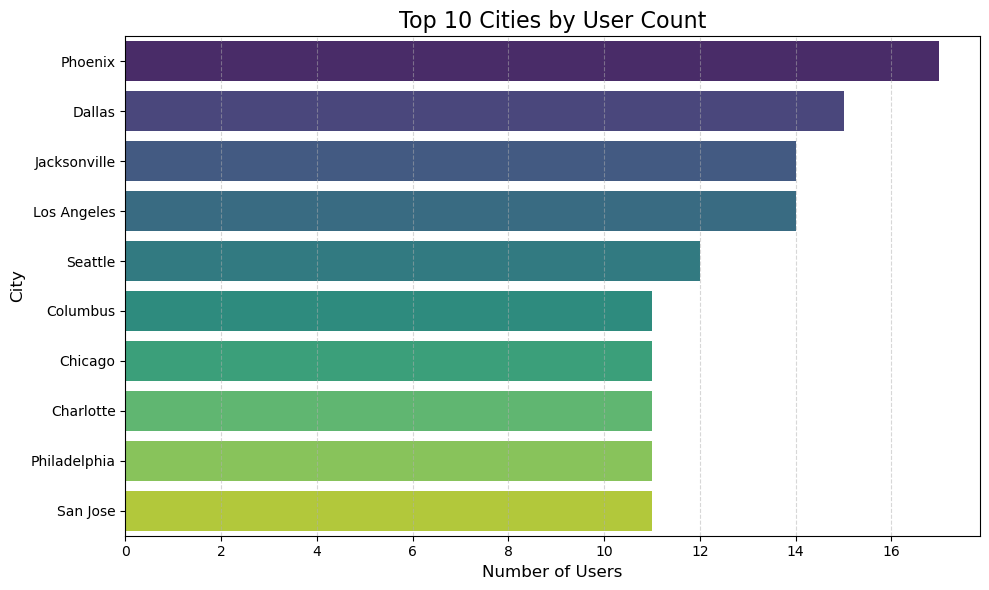

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_cities, x='User_Count', y='city', palette='viridis')
plt.title('Top 10 Cities by User Count', fontsize=16)
plt.xlabel('Number of Users', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Plot 2: Number of Users Per Gender

/tmp/ipykernel_33816/2668702671.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gender', palette='Set2')


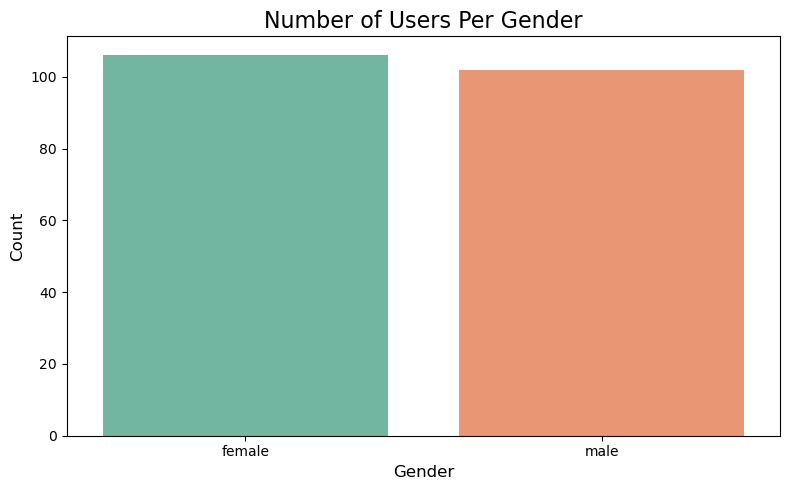

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='gender', palette='Set2')
plt.title('Number of Users Per Gender', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

### Plot 3: Average Age by Gender

/tmp/ipykernel_33816/2483579141.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='gender', y='age', estimator='mean', palette='coolwarm', errorbar=None)


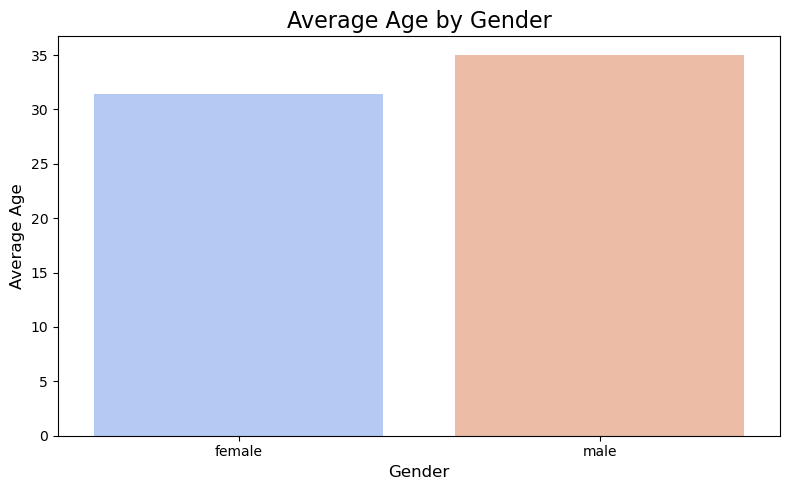

In [27]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='gender', y='age', estimator='mean', palette='coolwarm', errorbar=None)
plt.title('Average Age by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Age', fontsize=12)
plt.tight_layout()
plt.show()

### Plot 4: Age vs Height

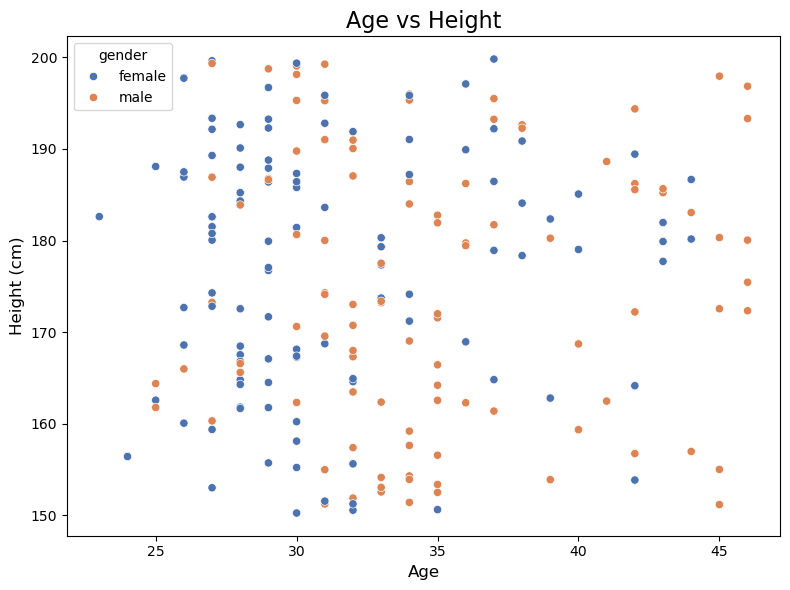

In [28]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='height', hue='gender', palette='deep')
plt.title('Age vs Height', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Height (cm)', fontsize=12)
plt.tight_layout()
plt.show()

### Plot 5: Age vs Weight

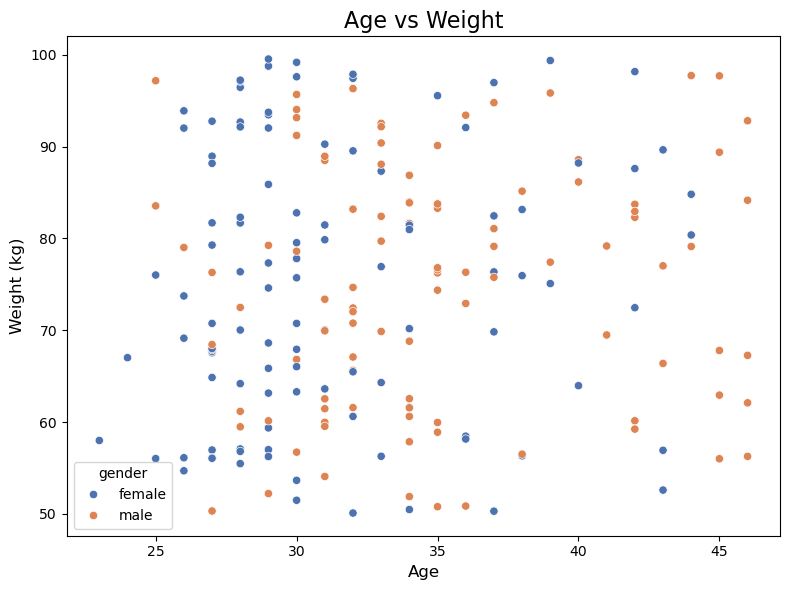

In [29]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='weight', hue='gender', palette='deep')
plt.title('Age vs Weight', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Weight (kg)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("users_transformed.csv")